## Exercise.
###Implement an End to End CNN Model for Image Classification Task.

### Objective
In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon
using TensorFlow and Keras.

### Task 1: Data Understanding and Visualization:

### Load & Display One Image per class

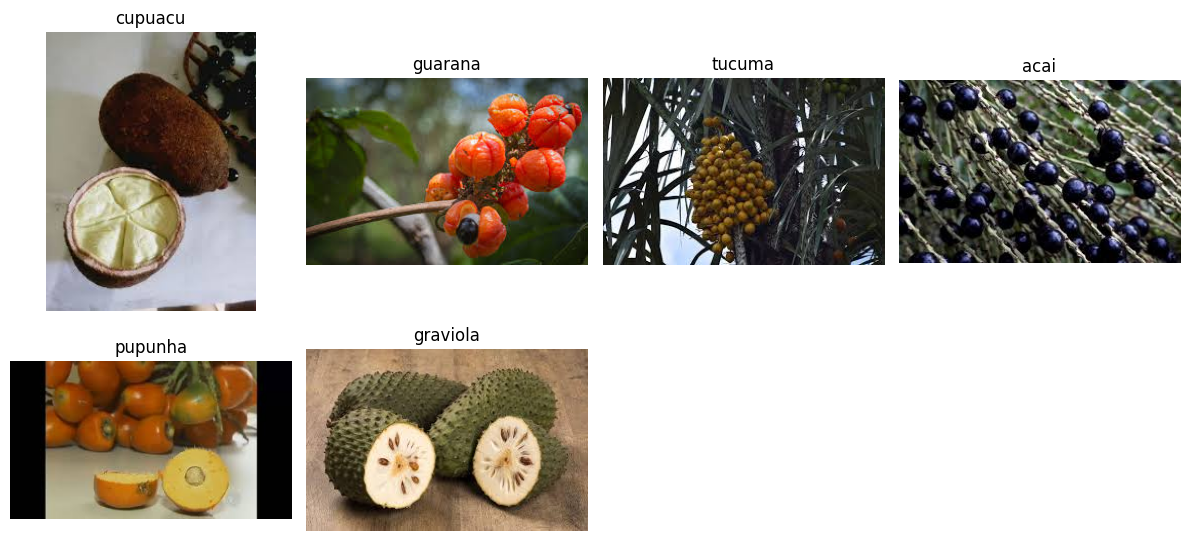

In [4]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI GOOGLE COLAB Y2S1/FruitinAmazon/train"

# Get class names (subdirectories)
classes = os.listdir(train_dir)

images = []

# Select one random image from each class
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    images.append((cls, img_path))

# Plot images (2 rows grid)
plt.figure(figsize=(12, 6))

for i, (cls, img_path) in enumerate(images):
    plt.subplot(2, len(images)//2 + 1, i+1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Check for Corrupted Images

In [5]:
from PIL import Image
import os

corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()  # check if corrupted

        except (IOError, SyntaxError):
            print(f"Removed corrupted image: {img_path}")
            os.remove(img_path)
            corrupted.append(img_path)

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


### Load & Preprocess Dataset

In [6]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalization
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


### Build CNN Model

In [7]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile Model

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.1655 - loss: 2.3338

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 519ms/step - accuracy: 0.1528 - loss: 2.5816 - val_accuracy: 0.6667 - val_loss: 1.5732
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.2778 - loss: 1.7559 - val_accuracy: 0.3333 - val_loss: 1.6138
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.2344 - loss: 1.7430

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - accuracy: 0.2500 - loss: 1.7300 - val_accuracy: 0.5556 - val_loss: 1.5691
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.3299 - loss: 1.6614

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 366ms/step - accuracy: 0.3333 - loss: 1.6427 - val_accuracy: 0.7778 - val_loss: 1.4283
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.4051 - loss: 1.5125

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.4028 - loss: 1.4975 - val_accuracy: 0.8333 - val_loss: 1.1072
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 325ms/step - accuracy: 0.5000 - loss: 1.3520 - val_accuracy: 0.6111 - val_loss: 1.3009
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step - accuracy: 0.5417 - loss: 1.2331 - val_accuracy: 0.2778 - val_loss: 1.6206
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.6638 - loss: 1.1110

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - accuracy: 0.6944 - loss: 1.0888 - val_accuracy: 0.6111 - val_loss: 1.0153
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8073 - loss: 0.8205

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step - accuracy: 0.7500 - loss: 0.8447 - val_accuracy: 0.8333 - val_loss: 0.7504
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step - accuracy: 0.8472 - loss: 0.6698 - val_accuracy: 0.5556 - val_loss: 1.0539
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8142 - loss: 0.5859

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 353ms/step - accuracy: 0.8333 - loss: 0.5657 - val_accuracy: 0.8333 - val_loss: 0.6220
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 0.9028 - loss: 0.3891 - val_accuracy: 0.7778 - val_loss: 0.6734
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 337ms/step - accuracy: 0.9028 - loss: 0.3158 - val_accuracy: 0.8889 - val_loss: 0.6286
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9497 - loss: 0.2263

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step - accuracy: 0.9583 - loss: 0.2081 - val_accuracy: 0.8889 - val_loss: 0.3416
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 0.9861 - loss: 0.1673 - val_accuracy: 0.8889 - val_loss: 0.4080
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step - accuracy: 1.0000 - loss: 0.0763 - val_accuracy: 0.7778 - val_loss: 0.6196
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step - accuracy: 0.9861 - loss: 0.0727 - val_accuracy: 0.8889 - val_loss: 0.3824
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 1.0000 - loss: 0.0427

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step - accuracy: 1.0000 - loss: 0.0437 - val_accuracy: 0.8889 - val_loss: 0.2505
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 392ms/step - accuracy: 1.0000 - loss: 0.0257 - val_accuracy: 0.8889 - val_loss: 0.2520
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 1.0000 - loss: 0.0170 - val_accuracy: 0.8889 - val_loss: 0.2699
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 333ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 0.8889 - val_loss: 0.3023
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 325ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.8889 - val_loss: 0.3487
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - accuracy: 1.0000 - loss: 0.0091 - val_accuracy: 0.8889 - val_loss: 0.3296
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.8889 - val_loss: 0.3068
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9444 - val_lo

### Evaluate Model

In [11]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8889 - loss: 0.2505
Validation Accuracy: 0.8888888955116272


### Save & Load Model

In [12]:
# Save
model.save("fruit_classifier.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_classifier.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.8889 - loss: 0.2505
Loaded Model Accuracy: 0.8888888955116272


### Predictions & Classification Report

In [16]:
import numpy as np
import os
from sklearn.metrics import classification_report

# ✅ Get class names safely (works even after .map())
class_names = sorted(os.listdir(train_dir))

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       1.00      0.67      0.80         3
      tucuma       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.32      0.27      0.29        18
weighted avg       0.94      0.89      0.91        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
